# Chapter 3 Application

## Installing Packages

In [ ]:
!pip install uv && uv pip install ISLP
import ISLP
print(ISLP.__version__)

path = "/content/drive/Othercomputers/My MacBook Pro/Professional Development/Data Science/ISLP/ISLP/"

Using Python 3.12.13 environment at: /usr
Checked 1 package in 96ms
0.4.1


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots

import statsmodels.api as sm
from statsmodels.stats.outliers_influence \
      import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

import seaborn as sns

## 8. Simple Linear Regression on Auto

In [ ]:
Auto = pd.read_csv(path + 'Datasets/Auto.csv', na_values="?")
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
394,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [ ]:
Auto = Auto.drop(columns={'cylinders', 'displacement', 'weight', 'acceleration', 'year', 'origin', 'name'})
Auto

,mpg,horsepower
0,18.0,130.0
1,15.0,165.0
2,18.0,150.0
3,16.0,150.0
4,17.0,140.0
...,...,...
392,27.0,86.0
393,44.0,52.0
394,32.0,84.0
395,28.0,79.0


In [ ]:
Auto.dtypes
Auto['horsepower'].isnull().sum()
Auto = Auto.dropna()
Auto

,mpg,horsepower
0,18.0,130.0
1,15.0,165.0
2,18.0,150.0
3,16.0,150.0
4,17.0,140.0
...,...,...
392,27.0,86.0
393,44.0,52.0
394,32.0,84.0
395,28.0,79.0


In [ ]:
X = pd.DataFrame({'intercept': np.ones(Auto.shape[0]),
                  'horsepower': Auto['horsepower']})
X

,intercept,horsepower
0,1.0,130.0
1,1.0,165.0
2,1.0,150.0
3,1.0,150.0
4,1.0,140.0
...,...,...
392,1.0,86.0
393,1.0,52.0
394,1.0,84.0
395,1.0,79.0


In [ ]:
y = Auto['mpg']
y

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
392,27.0
393,44.0
394,32.0
395,28.0


In [ ]:
# sm.OLS?
model1 = sm.OLS(y, X) # Specifying model
results1 = model1.fit() # Fitting the model
summarize(results1)

# There is a negative relationship between horsepower and mpg
# As the horsepower increases, the mpg decreases.
# The p-values for an intercept and horsepower are 0, thus,
# The relationship is significant.
# The R^2 is high, 0.6, meaning 60% of mpg variance is explained by horsepower

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


In [ ]:
results1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Sun, 05 Jul 2026   Prob (F-statistic):           7.03e-81
Time:                        22:45:13   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Predict 98
result1 = results1.get_prediction((1,98))

In [ ]:
# Predicted value
result1.predicted_mean

array([24.46707715])

In [ ]:
# Confidence Interval
result1.conf_int(obs=False, alpha=0.05)

array([[23.97307896, 24.96107534]])

In [ ]:
# Prediction Interval
result1.conf_int(obs=True, alpha=0.05)

array([[14.80939607, 34.12475823]])

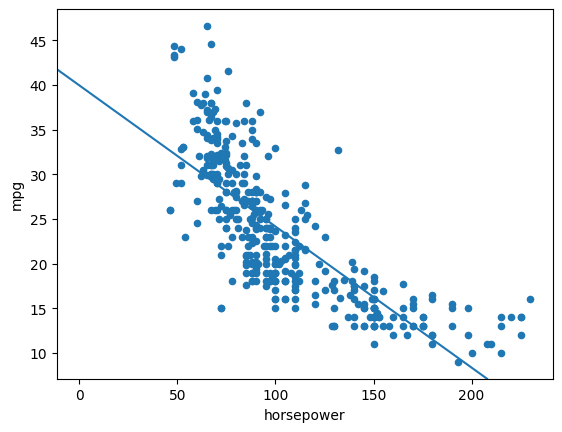

In [ ]:
# Plot the training data and regression line
ax = Auto.plot.scatter('horsepower', 'mpg')
ax.axline(xy1=(0, results1.params['intercept']), slope=results1.params['horsepower'])

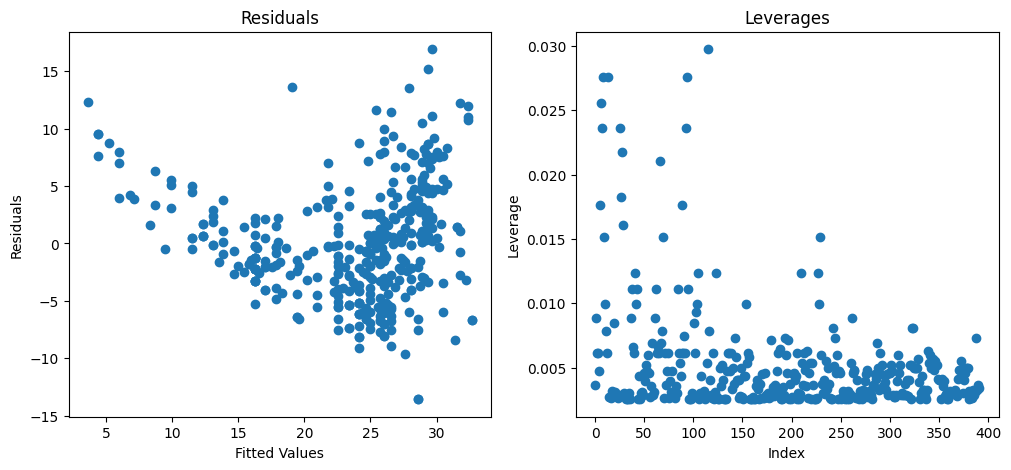

In [ ]:
# Plot the residuals
fig, axes = subplots(nrows=1, ncols=2, figsize=(12,5))
axes[0].scatter(results1.fittedvalues, results1.resid)
axes[0].set_title("Residuals")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
# Clearly visible U-shaped graph, the real model is not linear

# Plot the leverages
infl = results1.get_influence()
hmd = infl.hat_matrix_diag
axes[1].scatter(np.arange(Auto.shape[0]), hmd)
axes[1].set_title("Leverages")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Leverage");
# A few high-leverage points > 0.2, which might influence the model fit and performance


## 9. Multiple Linear Regression on Auto

In [ ]:
Auto = pd.read_csv(path + 'Datasets/Auto.csv', na_values="?")
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
394,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [ ]:
Auto = Auto.dropna()
Auto.dtypes
Auto = Auto.drop(columns='name')
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790,15.6,82,1
393,44.0,4,97.0,52.0,2130,24.6,82,2
394,32.0,4,135.0,84.0,2295,11.6,82,1
395,28.0,4,120.0,79.0,2625,18.6,82,1


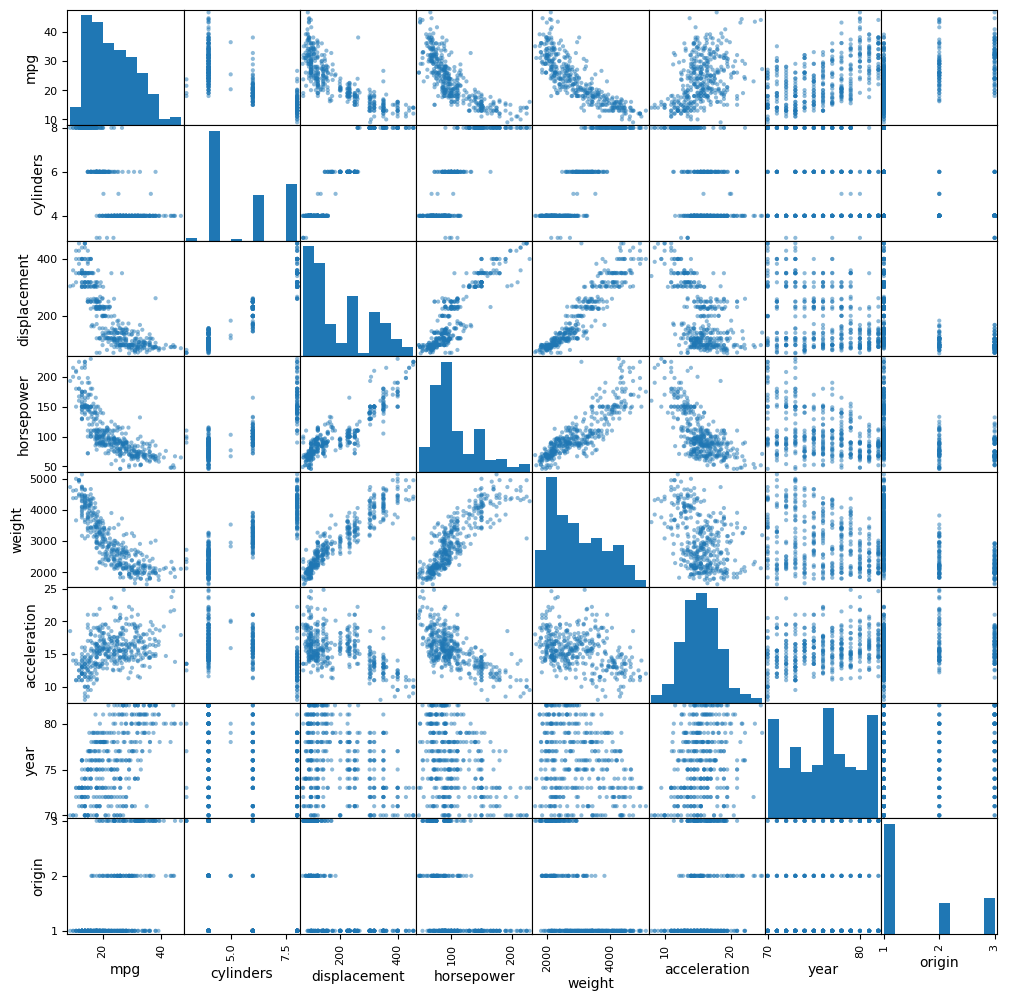

In [ ]:
pd.plotting.scatter_matrix(Auto, figsize=(12,12));

In [ ]:
Auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


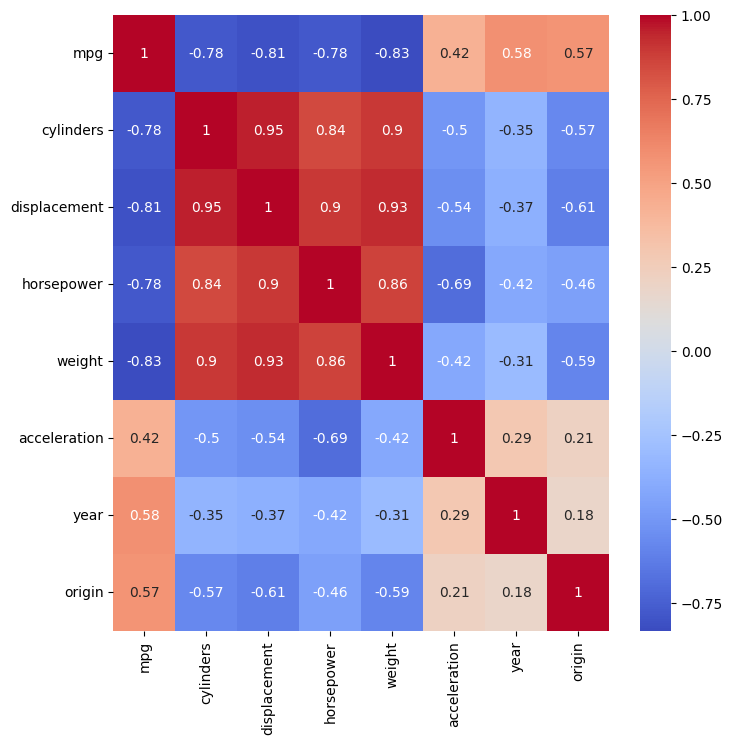

In [ ]:
plt.figure(figsize=(8, 8))
sns.heatmap(Auto.corr(), annot=True, cmap='coolwarm');

In [ ]:
cols = Auto.columns.to_list()
cols.remove('mpg')
X = MS(cols).fit_transform(Auto)
X

,intercept,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,1.0,8,307.0,130.0,3504,12.0,70,1
1,1.0,8,350.0,165.0,3693,11.5,70,1
2,1.0,8,318.0,150.0,3436,11.0,70,1
3,1.0,8,304.0,150.0,3433,12.0,70,1
4,1.0,8,302.0,140.0,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
392,1.0,4,140.0,86.0,2790,15.6,82,1
393,1.0,4,97.0,52.0,2130,24.6,82,2
394,1.0,4,135.0,84.0,2295,11.6,82,1
395,1.0,4,120.0,79.0,2625,18.6,82,1


In [ ]:
y = Auto['mpg']
y

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
392,27.0
393,44.0
394,32.0
395,28.0


In [ ]:
model2 = sm.OLS(y, X)
results2 = model2.fit()

summarize(results2)
# Displacement, weight, year, and origin have a statistically significant impact
# The year coeeficient suggests that if we keep all other predictors constant and
# only increase the year value by one unit, the response value changes by 0.7508 units

,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [ ]:
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Sun, 05 Jul 2026   Prob (F-statistic):          2.04e-139
Time:                        22:45:25   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
year             0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
anova_lm(results1, results2)
# The residual sum decresed almost by a half by adding only 6 more parameters
# The F-statisitc is high and the p-value is extremely low
# Thus, the evidence suggests the model has improved significantly
# And there must be relationship between the predictors and the response

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,390.0,9385.915872,0.0,NaN,NaN,NaN
1,384.0,4252.212530,6.0,5133.703341,77.267308,5.376746e-63


Text(0.5, 1.0, 'Leverages')

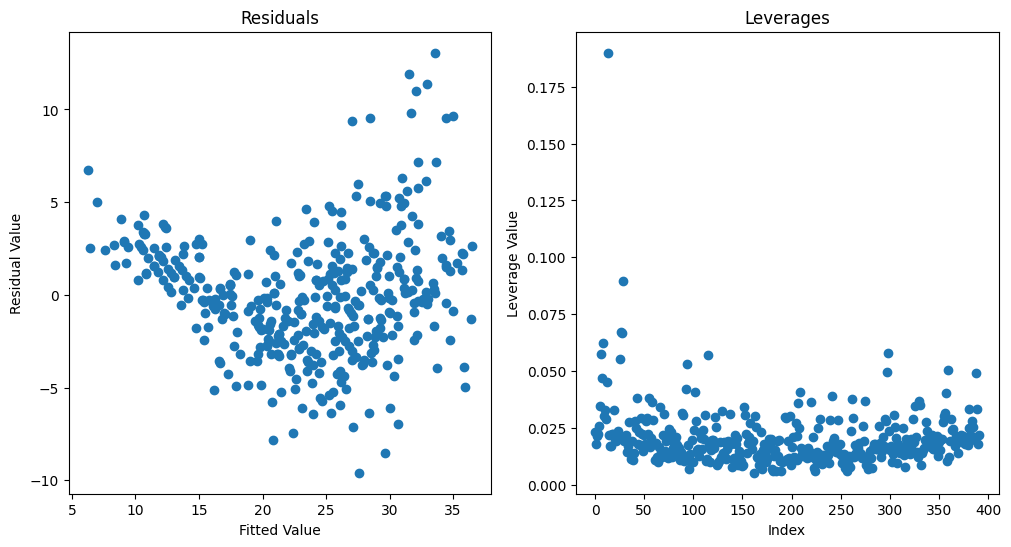

In [ ]:
# Residuals
fig, ax = subplots(ncols=2, figsize=(12,6))
ax[0].scatter(results2.fittedvalues, results2.resid)
ax[0].set_xlabel('Fitted Value')
ax[0].set_ylabel('Residual Value')
ax[0].set_title("Residuals")
# Strong suggestion of non-linearity of the real data fit (residuals are U-shaped)

# Leverages
infl2 = results2.get_influence()
hmd2 = infl2.hat_matrix_diag
ax[1].scatter(np.arange(Auto.shape[0]), hmd2)
ax[1].set_xlabel('Index')
ax[1].set_ylabel('Leverage Value')
ax[1].set_title("Leverages")
# The leverage graph has one distinct very high observation that might skew the fit (more below)

In [ ]:
avg_lev = (len(cols) + 1) / Auto.shape[0]
np.where(hmd2 > avg_lev * 3)[0]

# 5 data points exceed the average leverage threefold
# these might significantly skew the fit

array([ 8, 13, 26, 27, 28])

In [ ]:
# Interaction Models
cols21 = cols.copy()
cols21.append(('horsepower', 'acceleration'))
X = MS(cols21).fit_transform(Auto)
model21 = sm.OLS(y, X)
results21 = model21.fit()

cols22 = cols.copy()
cols22.append(('horsepower', 'displacement'))
X = MS(cols22).fit_transform(Auto)
model22 = sm.OLS(y, X)
results22 = model22.fit()

cols23 = cols.copy()
cols23.append(('horsepower', 'acceleration'))
cols23.append(('horsepower', 'displacement'))
X = MS(cols23).fit_transform(Auto)
model23 = sm.OLS(y, X)
results23 = model23.fit()

In [ ]:
summarize(results2)

,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [ ]:
summarize(results21)

,coef,std err,t,P>|t|
intercept,-32.4998,4.923,-6.601,0.000
cylinders,0.0835,0.317,0.263,0.792
displacement,-0.0076,0.008,-0.937,0.349
horsepower,0.1272,0.025,5.140,0.000
weight,-0.0040,0.001,-5.552,0.000
acceleration,0.9833,0.162,6.088,0.000
year,0.7559,0.048,15.690,0.000
origin,1.0357,0.269,3.851,0.000
horsepower:acceleration,-0.0121,0.002,-6.851,0.000


In [ ]:
summarize(results22)

,coef,std err,t,P>|t|
intercept,-1.8935,4.302000,-0.440,0.660
cylinders,0.6466,0.302000,2.143,0.033
displacement,-0.0749,0.011000,-6.859,0.000
horsepower,-0.1975,0.021000,-9.624,0.000
weight,-0.0031,0.001000,-4.861,0.000
acceleration,-0.2131,0.091000,-2.351,0.019
year,0.7379,0.045000,16.534,0.000
origin,0.6891,0.253000,2.727,0.007
horsepower:displacement,0.0005,0.000048,10.878,0.000


In [ ]:
summarize(results23)

,coef,std err,t,P>|t|
intercept,-4.0594,5.788000,-0.701,0.484
cylinders,0.6545,0.302000,2.165,0.031
displacement,-0.0735,0.011000,-6.569,0.000
horsepower,-0.1755,0.044000,-3.962,0.000
weight,-0.0030,0.001000,-4.517,0.000
acceleration,-0.1114,0.203000,-0.549,0.583
year,0.7389,0.045000,16.528,0.000
origin,0.6822,0.253000,2.694,0.007
horsepower:acceleration,-0.0012,0.002000,-0.560,0.576
horsepower:displacement,0.0005,0.000063,7.987,0.000


In [ ]:
# In separate models, interactions horsepower:acceleration and horsepower:displacement
# illustrate statistical significance. However, when both are included in the same model,
# the acceleration variable and its corresponding interaction both become insignifact and
# the displacment and displacement interaction absorb them both

In [ ]:
# Non-linear variable transformations

# ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']
Auto['log_disp'] = np.log(Auto['displacement'])
Auto['rt_accl'] = np.sqrt(Auto['acceleration'])
Auto['sq_horsepower'] = np.sqrt(Auto['horsepower'])

X = MS(['cylinders', 'log_disp', 'horsepower', 'weight', 'acceleration', 'year', 'origin']).fit_transform(Auto)
model31 = sm.OLS(y, X)
results31 = model31.fit()

X = MS(['cylinders', 'displacement', 'horsepower', 'weight', 'rt_accl', 'year', 'origin']).fit_transform(Auto)
model32 = sm.OLS(y, X)
results32 = model32.fit()

X = MS(['cylinders', 'displacement', 'sq_horsepower', 'weight', 'acceleration', 'year', 'origin']).fit_transform(Auto)
model33 = sm.OLS(y, X)
results33 = model33.fit()

In [ ]:
results2.summary()
# baseline

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Sun, 05 Jul 2026   Prob (F-statistic):          2.04e-139
Time:                        22:45:28   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
year             0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
results31.summary()
# R^2 improved, transformed variable statistically significant

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     258.1
Date:                Sun, 05 Jul 2026   Prob (F-statistic):          6.13e-141
Time:                        22:45:28   Log-Likelihood:                -1019.9
No. Observations:                 392   AIC:                             2056.
Df Residuals:                     384   BIC:                             2088.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept        2.3923      7.110      0.336      0.737     -11.588      16.372
cylinders        0.8053      0.308      2.614      0.009       0.199       1.411
log_disp        -5.2476      1.391     -3.772      0.000      -7.983      -2.513
horsepower      -0.0048      0.013     -0.371      0.711      -0.031       0.021
weight          -0.0045      0.001     -6.494      0.000      -0.006      -0.003
acceleration    -0.0047      0.099     -0.048      0.962      -0.199       0.189
year             0.7438      0.050     14.757      0.000       0.645       0.843
origin           0.6282      0.301      2.086      0.038       0.036       1.220
==============================================================================
Omnibus:                       37.749   Durbin-Watson:                   1.282
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               80.930
Skew:                           0.523   Prob(JB):                     2.67e-18
Kurtosis:                       4.965   Cond. No.                     1.34e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.34e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
results32.summary()
# R^2 stayed the same, transformed variable statistically insignificant

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.0
Date:                Sun, 05 Jul 2026   Prob (F-statistic):          2.64e-139
Time:                        22:45:28   Log-Likelihood:                -1023.7
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -16.9582      5.556     -3.052      0.002     -27.883      -6.033
cylinders       -0.5022      0.323     -1.553      0.121      -1.138       0.133
displacement     0.0197      0.008      2.604      0.010       0.005       0.035
horsepower      -0.0205      0.014     -1.464      0.144      -0.048       0.007
weight          -0.0063      0.001     -9.560      0.000      -0.008      -0.005
rt_accl          0.3086      0.810      0.381      0.703      -1.284       1.901
year             0.7490      0.051     14.687      0.000       0.649       0.849
origin           1.4281      0.278      5.131      0.000       0.881       1.975
==============================================================================
Omnibus:                       33.867   Durbin-Watson:                   1.308
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               58.049
Skew:                           0.547   Prob(JB):                     2.48e-13
Kurtosis:                       4.536   Cond. No.                     1.03e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.03e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
results33.summary()
# R^2 improved, transformed variable statistically significant

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     262.0
Date:                Sun, 05 Jul 2026   Prob (F-statistic):          5.83e-142
Time:                        22:45:28   Log-Likelihood:                -1017.5
No. Observations:                 392   AIC:                             2051.
Df Residuals:                     384   BIC:                             2083.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
intercept        -6.0374      5.546     -1.089      0.277     -16.942       4.867
cylinders        -0.5223      0.317     -1.649      0.100      -1.145       0.100
displacement      0.0221      0.007      3.064      0.002       0.008       0.036
sq_horsepower    -1.1435      0.311     -3.672      0.000      -1.756      -0.531
weight           -0.0055      0.001     -7.979      0.000      -0.007      -0.004
acceleration     -0.1021      0.104     -0.983      0.326      -0.306       0.102
year              0.7240      0.050     14.429      0.000       0.625       0.823
origin            1.5173      0.270      5.612      0.000       0.986       2.049
==============================================================================
Omnibus:                       32.516   Durbin-Watson:                   1.343
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.556
Skew:                           0.542   Prob(JB):                     2.35e-12
Kurtosis:                       4.451   Cond. No.                     1.04e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.04e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 10. Multiple Linear Regression on Carseats

In [ ]:
Carseats = pd.read_csv(path + 'Datasets/Carseats.csv')

# Convert String object into category (MS parses only categories into OHE)
Carseats['Urban'] = Carseats['Urban'].astype('category')
Carseats['US'] = Carseats['US'].astype('category')

X = MS(['Price', 'Urban', 'US']).fit_transform(Carseats)
y = Carseats['Sales']

X, y

(     intercept  Price  Urban[Yes]  US[Yes]
 0          1.0    120         1.0      1.0
 1          1.0     83         1.0      1.0
 2          1.0     80         1.0      1.0
 3          1.0     97         1.0      1.0
 4          1.0    128         1.0      0.0
 ..         ...    ...         ...      ...
 395        1.0    128         1.0      1.0
 396        1.0    120         0.0      1.0
 397        1.0    159         1.0      1.0
 398        1.0     95         1.0      1.0
 399        1.0    120         1.0      1.0
 
 [400 rows x 4 columns],
 0       9.50
 1      11.22
 2      10.06
 3       7.40
 4       4.15
        ...  
 395    12.57
 396     6.14
 397     7.41
 398     5.94
 399     9.71
 Name: Sales, Length: 400, dtype: float64)

In [ ]:
model4 = sm.OLS(y, X)
results4 = model4.fit()
results4.summary()

# y-hat = 13.0435 - 0.0545 * Price - 0.0219 * Urban + 1.2006 * US
# If we keep all predictors constant and increase Price by one unit, Sales decrease by 0.0545.
# If we keep all predictors constant but choose Urban setting, Sales decrease by 0.0219,
# or stores in urban areas are predicted to have 0.0219 fewer Sales than non-urban stores.
# If we keep all predictors constant but choose US, Sales increase by 1.2006,
# or stores in the US are predicted to have 1.2006 more Sales than stores outside the US.
# The intercept points to the number of sales if the Price is 0 and we're in non-urban setting outside the US

# The Urban predictor is not statistically significant. Its p-value is 0.936, and the t-statistic is close to 0
# Also, the confidence interval contains 0 almost in the middle of the interval.
# These mean that we fail to reject the null-hypothesis for Urban predictor.

# On the other hand, Price and US p-values suggest that we can reject their null-hypothesis

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Sun, 05 Jul 2026   Prob (F-statistic):           2.39e-23
Time:                        22:45:28   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0435      0.651     20.036      0.000      11.764      14.323
Price         -0.0545      0.005    -10.389      0.000      -0.065      -0.044
Urban[Yes]    -0.0219      0.272     -0.081      0.936      -0.556       0.512
US[Yes]        1.2006      0.259      4.635      0.000       0.691       1.710
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.758
Skew:                           0.093   Prob(JB):                        0.684
Kurtosis:                       2.897   Cond. No.                         628.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
X = MS(['Price', 'US']).fit_transform(Carseats)

model41 = sm.OLS(y, X)
results41 = model41.fit()

results41.summary()

# Both first and second models have relatively low R^2 values of 0.239.
# That means that the models explains only ~24% of the variablility in Sales
# However, both also have high F-statistic, meaning that there must be some relationship
# between the predictors and predicted value. The removal of Urban variable
# didn't change the explanatory power of the model, additonally proving that it is
# not statistically significant

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Sun, 05 Jul 2026   Prob (F-statistic):           2.66e-24
Time:                        22:45:28   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0308      0.631     20.652      0.000      11.790      14.271
Price         -0.0545      0.005    -10.416      0.000      -0.065      -0.044
US[Yes]        1.1996      0.258      4.641      0.000       0.692       1.708
==============================================================================
Omnibus:                        0.666   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.717   Jarque-Bera (JB):                0.749
Skew:                           0.092   Prob(JB):                        0.688
Kurtosis:                       2.895   Cond. No.                         607.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# 95% Confidence Interval
results41.conf_int(alpha=0.05)

,0,1
intercept,11.79032,14.271265
Price,-0.06476,-0.044195
US[Yes],0.69152,1.707766


array([ 42, 125, 165, 171, 174, 313, 367])

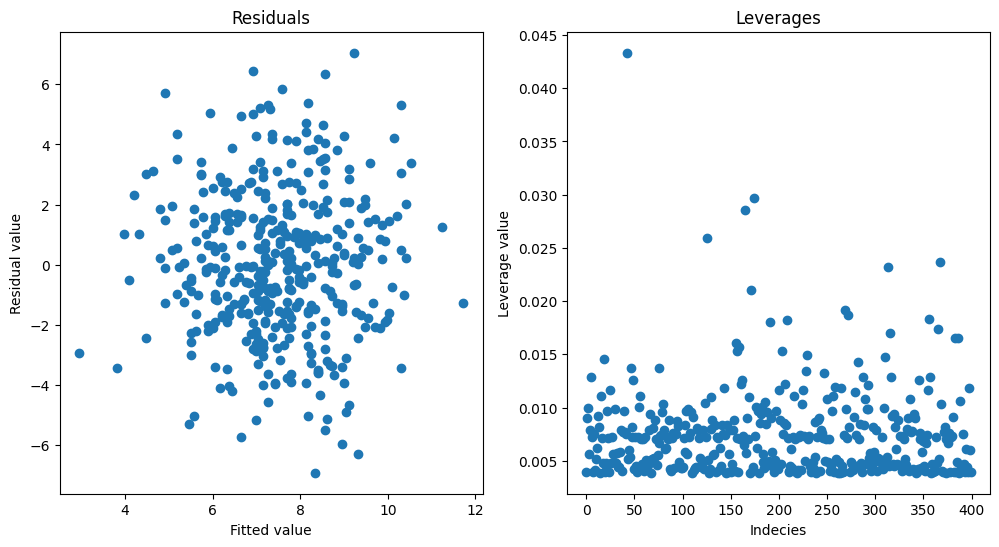

In [ ]:
fig, ax = subplots(ncols=2, figsize=(12,6))

# Residuals
ax[0].scatter(results41.fittedvalues, results41.resid)
ax[0].set_ylabel('Residual value')
ax[0].set_xlabel('Fitted value')
ax[0].set_title('Residuals')
# No clear pattern / almost unifrom distribution

# Leverages
infl3 = results41.get_influence()
hmd3 = infl3.hat_matrix_diag
ax[1].scatter(np.arange(Carseats.shape[0]), hmd3)
ax[1].set_ylabel('Leverage value')
ax[1].set_xlabel('Indecies')
ax[1].set_title('Leverages')
# Potential leverages present

avg_lev2 = (3+1) / Carseats.shape[0]
np.where(hmd3 > avg_lev2 * 2)[0]
# 7 high-leverage points

## 11. Null-hypothesis, t-statistic in Linear Regression w/o intercept

In [ ]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = 2 * x + rng.normal(size=100)

# y onto x
model51 = sm.OLS(y, x)
results51 = model51.fit()
results51.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.743
Model:                            OLS   Adj. R-squared (uncentered):              0.740
Method:                 Least Squares   F-statistic:                              285.6
Date:                Sun, 05 Jul 2026   Prob (F-statistic):                    6.23e-31
Time:                        22:45:29   Log-Likelihood:                         -141.35
No. Observations:                 100   AIC:                                      284.7
Df Residuals:                      99   BIC:                                      287.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             1.9762      0.117     16.898      0.000       1.744       2.208
==============================================================================
Omnibus:                        1.376   Durbin-Watson:                   2.184
Prob(Omnibus):                  0.503   Jarque-Bera (JB):                0.847
Skew:                           0.121   Prob(JB):                        0.655
Kurtosis:                       3.381   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
summarize(results51)

# The standard error is small compared to the coefficient estimate
# Thus, the t-statistic is high. The H_0 is rejected; the model suggests
# relationship between the predictor and the predicted value
# An increase in x by one unit yields an increase of 1.9762 in response value

,coef,std err,t,P>|t|
x1,1.9762,0.117,16.898,0.0


In [ ]:
# x onto y
model52 = sm.OLS(x, y)
results52 = model52.fit()
results52.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.743
Model:                            OLS   Adj. R-squared (uncentered):              0.740
Method:                 Least Squares   F-statistic:                              285.6
Date:                Sun, 05 Jul 2026   Prob (F-statistic):                    6.23e-31
Time:                        22:45:29   Log-Likelihood:                         -58.349
No. Observations:                 100   AIC:                                      118.7
Df Residuals:                      99   BIC:                                      121.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.3757      0.022     16.898      0.000       0.332       0.420
==============================================================================
Omnibus:                       13.156   Durbin-Watson:                   2.034
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               22.596
Skew:                          -0.528   Prob(JB):                     1.24e-05
Kurtosis:                       5.075   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
summarize(results52)

# The standard error is small compared to the coefficient estimate
# Thus, the t-statistic is high. The H_0 is rejected; the model suggests
# relationship between the predictor and the predicted value
# An increase in y by one unit yields an increase of 0.3757 in response value

,coef,std err,t,P>|t|
x1,0.3757,0.022,16.898,0.0


In [ ]:
# y-hat = b_1 * x
# x-hat = b_2 * y

# The t-statistic is the same for both
# However, b_1 != 1/b_2

b_1 = results51.params[0]
b_2 = results52.params[0]

print(b_1, b_2, 1/b_1, 1/b_2)

1.9762423774420512 0.37574368103348865 0.5060108068800496 2.661388735133176


$$
b_1 = \frac{\sum x_i y_i}{\sum x_i^2}
$$

$$
b_2 = \frac{\sum x_i y_i}{\sum y_i^2}
$$

$$
\frac{\sum x_i y_i}{\sum x_i^2}
\neq
\frac{\sum y_i^2}{\sum x_i y_i}
$$

Ordinary least squares is asymmetric
- Regressing y on x minimizes vertical squared errors $\sum (y_i - \hat{y})^2$
- Regressing x on y minimizes horizontal squared errors: $\sum (x_i - \hat{x})^2$

[Visualized assymetry](https://i.sstatic.net/jSpYk.png)

Thus, b_1 != 1/b_2

$$
b = \frac{\sum x_i y_i}{\sum x_i^2}
$$

$$
SE(b) = \sqrt{\frac{\sum (y_i-x_ib)^2}{(n-1)\sum x_i^2}}
$$

$$
t = \frac{b}{SE(b)}
$$

$$
\frac{\frac{\sum x_i y_i}{\sum x_i^2}}{\sqrt{\frac{\sum (y_i-x_ib)^2}{(n-1)\sum x_i^2}}}
$$


$$
\begin{aligned}
& \frac{\sum x_i y_i}{\sum x_i^2} \cdot \frac{\sqrt{(n-1) \sum x_i^2}}{\sqrt{\sum (y_i - x_i b)^2}} \\[10pt]
&= \frac{\sum x_i y_i}{\sum x_i^2} \cdot \sqrt{(n-1)} \cdot \sqrt{\sum x_i^2} \cdot \frac{1}{\sqrt{\sum \left( y_i - x_i \frac{\sum x_i y_i}{\sum x_i^2} \right)^2}} \\[10pt]
&= \frac{\sum x_i y_i}{\sqrt{\sum x_i^2}} \cdot (\sqrt{(n-1)}) \cdot \frac{1}{\sqrt{\sum \left( y_i - x_i \frac{\sum x_i y_i}{\sum x_i^2} \right)^2}} \\[10pt]
&= \frac{(\sqrt{(n-1)}) \sum x_i y_i}{\sqrt{\sum x_i^2}} \cdot \frac{1}{\sqrt{\sum \left( y_i - x_i \frac{\sum x_i' y_i'}{\sum x_i'^2} \right)^2}} \\[10pt]
&= \frac{(\sqrt{(n-1)}) \sum x_i y_i}{\sqrt{\sum x_i^2}} \cdot \frac{1}{\sqrt{\sum (y_i - x_i b)^2}} \\[10pt]
&= \frac{(\sqrt{(n-1)}) \sum x_i y_i}{\sqrt{\sum x_i^2}} \cdot \frac{1}{\sqrt{\sum y_i^2 - 2y_i x_i b + b^2 x_i^2}} \\[10pt]
&= \frac{(\sqrt{(n-1)}) \sum x_i y_i}{\sqrt{\sum x_i^2}} \cdot \frac{1}{\sqrt{\sum y_i^2 - \sum 2y_i x_i b + b^2 \sum x_i^2}} \\[10pt]
&= \frac{(\sqrt{(n-1)}) \sum x_i y_i}{\sqrt{\sum x_i^2}} \cdot \frac{1}{\sqrt{\sum y_i^2 - 2b \sum y_i x_i + b^2 \sum x_i^2}} \\[10pt]
&= \frac{(\sqrt{(n-1)}) \sum x_i y_i}{\sqrt{\sum x_i^2}} \cdot \frac{1}{\sqrt{\sum y_i^2 + b(-2\sum y_i x_i + b \sum x_i^2)}} \\[10pt]
&= \frac{(\sqrt{(n-1)}) \sum x_i y_i}{\sqrt{\sum x_i^2}} \cdot \frac{1}{\sqrt{\sum y_i^2 + b(-2\sum y_i x_i + \sum y_i x_i)}} \\[10pt]
&= \frac{(\sqrt{(n-1)}) \sum x_i y_i}{\sqrt{\sum x_i^2}} \cdot \frac{1}{\sqrt{\sum y_i^2 - b \sum y_i x_i}} \\[10pt]
&= \frac{(\sqrt{(n-1)}) \sum x_i y_i}{\sqrt{\sum x_i^2}} \cdot \frac{1}{\sqrt{\sum y_i^2 - \frac{(\sum x_i y_i)^2}{\sum x_i^2}}} \\[10pt]
&= (\sqrt{(n-1)}) \sum x_i y_i \cdot \frac{1}{\sqrt{\sum x_i^2 \sum y_i^2 - (\sum x_i y_i)^2}} \\[10pt]
&= \frac{(\sqrt{(n-1)}) \sum x_i y_i}{\sqrt{\sum x_i^2 \sum y_i^2 - (\sum x_i y_i)^2}}
\end{aligned}
$$

In [ ]:
# Computed t-value
results51.tvalues

array([16.89841706])

In [ ]:
# Derived t-value
xy_sum = np.sum(x*y)
x_sq_sum = np.sum(x**2)
y_sq_sum = np.sum(y**2)

numerator = np.sqrt(x.size - 1) * xy_sum
denominator = np.sqrt((x_sq_sum * y_sq_sum) - (xy_sum**2))
t_stat_formula = numerator / denominator

t_stat_formula

# t-statisitic for x onto y must be the same as y onto x because
# two variables switch places in the derived formula and only symmetric
# multiplications are performed which result in the same values for both.

np.float64(16.898417063035094)

In [ ]:
# y onto x
X = pd.DataFrame(x)
X.columns = ['x']
X = MS('x').fit_transform(X)

model53 = sm.OLS(y, X)
results53 = model53.fit()

# x onto y
Y = pd.DataFrame(y)
Y.columns = ['Y']
Y = MS('Y').fit_transform(Y)

model54 = sm.OLS(x, Y)
results54 = model54.fit()

# Approximately equal t-values of x onto y and y onto x w/ an intercept
assert np.isclose(results53.tvalues.iloc[1], results54.tvalues.iloc[1])
print('Approximately equal t-values of x onto y and y onto x w/ an intercept')

Approximately equal t-values of x onto y and y onto x w/ an intercept


## 12. Coefficient of a Simple Linear Regression w/o an intercept

$\hat{\beta} = \frac{\sum_{i=1}^{n} x_i y_i}{\sum_{i=1}^{n} x_i^2}$

The coefficient will be the same in regression of y onto x as in x onto y only if the squared sum of the predictor will be the same in both. One such case occurs when arrays x and y are equal.

In [ ]:
# Different coefficients
rng = np.random.default_rng(15)
x = rng.normal(size=100)
y = rng.normal(size=100) + x * 15

model61 = sm.OLS(y, x)
results61 = model61.fit()

model62 = sm.OLS(x, y)
results62 = model62.fit()

assert not np.isclose(results61.params[0], results62.params[0])
print('Different Coefficients')
results61.params[0], results62.params[0]

Different Coefficients


(np.float64(15.04398935293096), np.float64(0.06620148373635173))

In [ ]:
# The same coefficients
rng = np.random.default_rng(17)
x = rng.normal(size=100)
y = x

model63 = sm.OLS(y, x)
results63 = model63.fit()

model64 = sm.OLS(x, y)
results64 = model64.fit()

assert np.isclose(results63.params[0], results64.params[0])
print('The same coefficients')
results63.params[0], results64.params[0]

The same coefficients


(np.float64(1.0000000000000002), np.float64(1.0000000000000002))

## 13. Linear Regression in Simulated Data

In [ ]:
def model_simulation(stderr):
  # Simulating data
  rng = np.random.default_rng(1)
  x = rng.normal(size=100)
  eps = rng.normal(loc=0, scale=stderr, size=100)
  y = -1 + 0.5 * x + eps

  # Running Regression
  X = pd.DataFrame(x)
  X.columns = ['x']
  X = MS('x').fit_transform(X)

  model7 = sm.OLS(y, X)
  results7 = model7.fit()

  print('Linear Regression Summary')
  print(results7.summary())

  # Plotting data
  fig, ax = subplots(figsize=(10, 5))
  ax.scatter(x=x, y=y)
  ax.set_xlabel('x')
  ax.set_ylabel('y')

  reg_line = ax.axline(xy1=(0, results7.params[0]), slope=results7.params[1], label='Regression Line')
  pop_line = ax.axline(xy1=(0, -1), slope=0.5, c='r', label='Population Line')
  ax.legend(handles=[reg_line, pop_line])
  ax.set_title('Regression on Simulated Data of y = 0.5 * x - 1')

  # Polynomial Fit
  X = pd.DataFrame(x)
  X.columns = ['x']
  X = MS([poly('x', degree=2)]).fit_transform(X)

  model7s = sm.OLS(y, X)
  results7s = model7s.fit()

  print('\n\n\nPolynomial Regression Summary')
  print(results7s.summary())

  return results7

Linear Regression Summary
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     280.0
Date:                Sun, 05 Jul 2026   Prob (F-statistic):           1.74e-30
Time:                        22:45:29   Log-Likelihood:                -2.4306
No. Observations:                 100   AIC:                             8.861
Df Residuals:                      98   BIC:                             14.07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.0190     

/tmp/ipykernel_17116/4195497119.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  reg_line = ax.axline(xy1=(0, results7.params[0]), slope=results7.params[1], label='Regression Line')


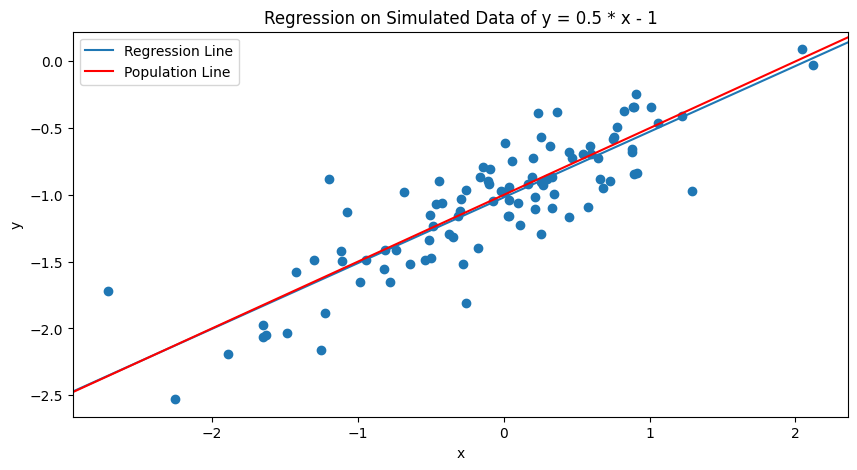

In [ ]:
# Baseline Model
results71 = model_simulation(0.25)

# y vector length is 100, b_0 = -1, b_1 = 0.5

# Highly linear pattern (low dispersion and high uniformity) with a possible negative y-intercept
# Positive relationhsip between x and y

# b-hat_0 ~ b_0, b-hat_1 ~ b_1
# coefficients statisically significant (high t-values, 0 p-values)
# coeff +- std err intersect real coeffs

# The model fit was not improved after adding a polynomial factor of x
# The R^2 remained the same while the t-statistic for x^2 turned out to be
# close to 0, yielding a p-value of 96%; the x^2 thus is not statistically significant

Linear Regression Summary
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     1784.
Date:                Sun, 05 Jul 2026   Prob (F-statistic):           1.08e-64
Time:                        22:45:30   Log-Likelihood:                 89.198
No. Observations:                 100   AIC:                            -174.4
Df Residuals:                      98   BIC:                            -169.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.0076     

/tmp/ipykernel_17116/4195497119.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  reg_line = ax.axline(xy1=(0, results7.params[0]), slope=results7.params[1], label='Regression Line')


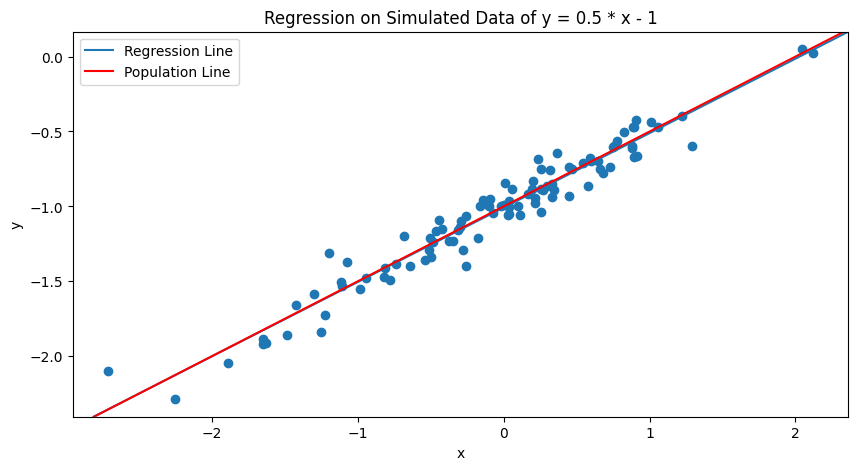

In [ ]:
# Less Noisy Model
results72 = model_simulation(0.10)

# The less noisy model has a higher R^squred value, its coefficients are more
# precise and closer to the real coefficients. The t-statistics are higher due
# to smaller standard error coming from noise

Linear Regression Summary
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.523
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     107.3
Date:                Sun, 05 Jul 2026   Prob (F-statistic):           2.02e-17
Time:                        22:45:31   Log-Likelihood:                -49.431
No. Observations:                 100   AIC:                             102.9
Df Residuals:                      98   BIC:                             108.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.0304     

/tmp/ipykernel_17116/4195497119.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  reg_line = ax.axline(xy1=(0, results7.params[0]), slope=results7.params[1], label='Regression Line')


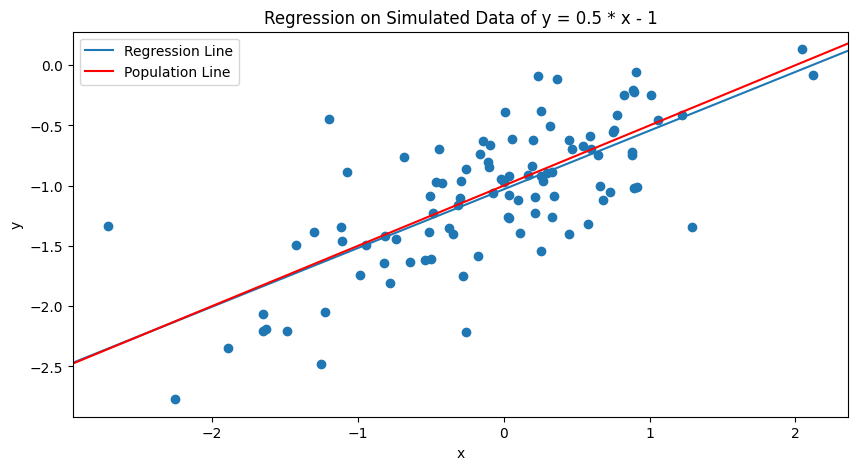

In [ ]:
# More Noisy Model
results73 = model_simulation(0.40)

# The more noisy model has a lower R^squred value, its coefficients are less
# precise and farther from the real coefficients. The t-statistics are lower due
# to higher standard error coming from noise

In [ ]:
# Confidence Intervals

print('Less Noisy CI:')
print(results72.conf_int())

print('\nBaseline CI:')
print(results71.conf_int())

print('\nMore Noisy CI:')
print(results73.conf_int())

# Condidence Intervals get narrower as the noise variable decrease, as expected

Less Noisy CI:
                  0         1
intercept -1.027556 -0.987649
x          0.473513  0.520203

Baseline CI:
                  0         1
intercept -1.068891 -0.969122
x          0.433783  0.550508

More Noisy CI:
                  0         1
intercept -1.110226 -0.950595
x          0.394052  0.580813


## 14. Collinearity

In [ ]:
# Simulating data
rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

# y = b_0 + b_1 * x_1 + b_2 * x_2 + eps
# y = 2 + 2 * x_1 + 0.3 * x_2
# b_0 = 2, b_1 = 2, b_2 = 0.3, eps ~ N(0, 1)

Correlation between x1 and x2: 0.772324497691354


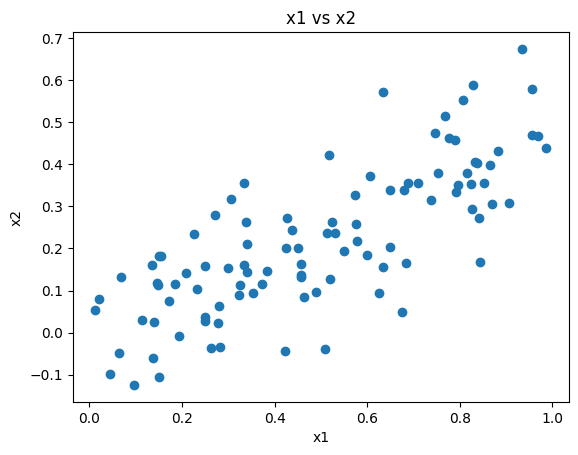

In [ ]:
# Correlation between two predictors
plt.scatter(x=x1, y=x2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('x1 vs x2')
corr_coef = np.corrcoef(x1,x2)[0, 1]
print('Correlation between x1 and x2: {}'.format(corr_coef))

In [ ]:
def corr_models(x1, x2, y):
  # Baseline
  X = pd.DataFrame(data={'x1': x1, 'x2': x2})
  X = MS(['x1', 'x2']).fit_transform(X)
  model8 = sm.OLS(y, X)
  results8 = model8.fit()

  print('Baseline Mode. R^2: {}'.format(results8.rsquared))
  print(summarize(results8))

  # X1 only
  X1 = pd.DataFrame(data = {'x1': x1})
  X1 = MS(['x1']).fit_transform(X1)
  model81 = sm.OLS(y, X1)
  results81 = model81.fit()

  print('\n\nX1 Only Model. R^2: {}'.format(results81.rsquared))
  print(summarize(results81))

  # X2 only
  X2 = pd.DataFrame(data = {'x2': x2})
  X2 = MS(['x2']).fit_transform(X2)
  model82 = sm.OLS(y, X2)
  results82 = model82.fit()

  print('\n\nX2 Only Model. R^2: {}'.format(results82.rsquared))
  print(summarize(results82))

  return results8, results81, results82

c. **Baseline (both x1 and x2)**:

b-hat_0 = 1.96, b-hat_1 = 1.62, b-hat_2 = 0.94
The intercept is about the same; however, the b_1 and b_2
coefficients have deviated from their real values.

The null-hypothesis can be only rejected for b_0 and b_1
their t-statistics are high enough and p-values are below the 5% threshold
However, the null-hypothesis can't be rejected for b_2 since its std err is
close to the magnitude of the coefficient, leading to small t-statisic, and,
thus, high p-value. Also, the CI includes 0. The R^2 is also low.

As expected, x2 might not be statisitcally significant due to high correlation w/ x1



---



d. **Only x1:**

 The R^2 value is still low. The b_0 and b_1 coefficients are close to their
real values. Their t-statistics are high and p-values are essentially 0.
Thus, the null-hypothesis can be rejected for both.



---



e. **Only x2:**

The R^2 value is still low. The b_0 coefficient is close to its
real value. However, for both b_0 and b_2 t-statistics are high and p-values
are essentially 0. Thus, the null-hypothesis can be rejected for both.
However, the coefficient of b_2 is not close to its real value.



---



f. **Comparing d & e:**

 The results make sense due to high correlation between x1 and x2.
The 2nd and 3rd models have essentially computed the regression slope by taking
advantage of the correlation with the corresponding real predictor, which has a
shifted the coefficient to be closer to a value that the higher weight predictor
had. Thus, the coefficients in 2nd and 3rd models are still closer to the prevailing
x1 coefficient which has more weight than x2.

In [ ]:
corr_models(x1, x2, y);

Baseline Mode. R^2: 0.2908714510187439
             coef  std err       t  P>|t|
intercept  1.9579    0.190  10.319  0.000
x1         1.6154    0.527   3.065  0.003
x2         0.9428    0.831   1.134  0.259


X1 Only Model. R^2: 0.2814635507431502
             coef  std err       t  P>|t|
intercept  1.9371    0.189  10.242    0.0
x1         2.0771    0.335   6.196    0.0


X2 Only Model. R^2: 0.22217640363594238
             coef  std err       t  P>|t|
intercept  2.3239    0.154  15.124    0.0
x2         2.9103    0.550   5.291    0.0


In [ ]:
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])

base, x1_only, x2_only = corr_models(x1, x2, y)

Baseline Mode. R^2: 0.29162832021142104
             coef  std err       t  P>|t|
intercept  2.0618    0.192  10.720  0.000
x1         0.8575    0.466   1.838  0.069
x2         2.2663    0.705   3.216  0.002


X1 Only Model. R^2: 0.21687081476133252
             coef  std err       t  P>|t|
intercept  2.0739    0.201  10.310    0.0
x1         1.8760    0.358   5.236    0.0


X2 Only Model. R^2: 0.2672009562601295
             coef  std err       t  P>|t|
intercept  2.2840    0.151  15.088    0.0
x2         3.1458    0.524   6.008    0.0


In [ ]:
def out_lev(fit_mod, p, n):
  fig, ax = subplots(ncols=2, figsize=(12,6))

  infl = fit_mod.get_influence()

  # Outliars
  stud_res = infl.resid_studentized
  ax[0].scatter(fit_mod.fittedvalues, fit_mod.resid)
  ax[0].set_ylabel('Residual value')
  ax[0].set_xlabel('Fitted value')
  ax[0].set_title('Residuals')

  print('Indecies of outliars: {}'.format(np.where(np.abs(stud_res) > 2)[0]))

  # Leverages
  lev = infl.hat_matrix_diag
  ax[1].scatter(np.arange(n), lev)
  ax[1].set_ylabel('Leverage value')
  ax[1].set_xlabel('Indecies')
  ax[1].set_title('Leverages')

  avg_lev = (p + 1) / n
  print('Indecies of leverages: {}'.format(np.where(lev > avg_lev * 2)[0]))

New correlation between x1 and x2: 0.6789150824876988


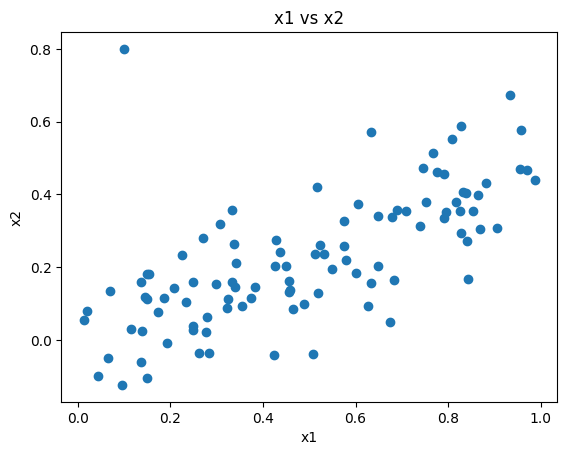

In [ ]:
# New correlation between two predictors
plt.scatter(x=x1, y=x2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('x1 vs x2')
corr_coef = np.corrcoef(x1,x2)[0, 1]
print('New correlation between x1 and x2: {}'.format(corr_coef))

Baseline Model
Indecies of outliars: [ 32  36  88  99 100]
Indecies of leverages: [ 15 100]


X1 Only Model
Indecies of outliars: [ 36  88  99 100]
Indecies of leverages: [23 52 98]


X2 Only Model
Indecies of outliars: [32 36 43 99]
Indecies of leverages: [  2   9  15  35  53  84  89  92 100]


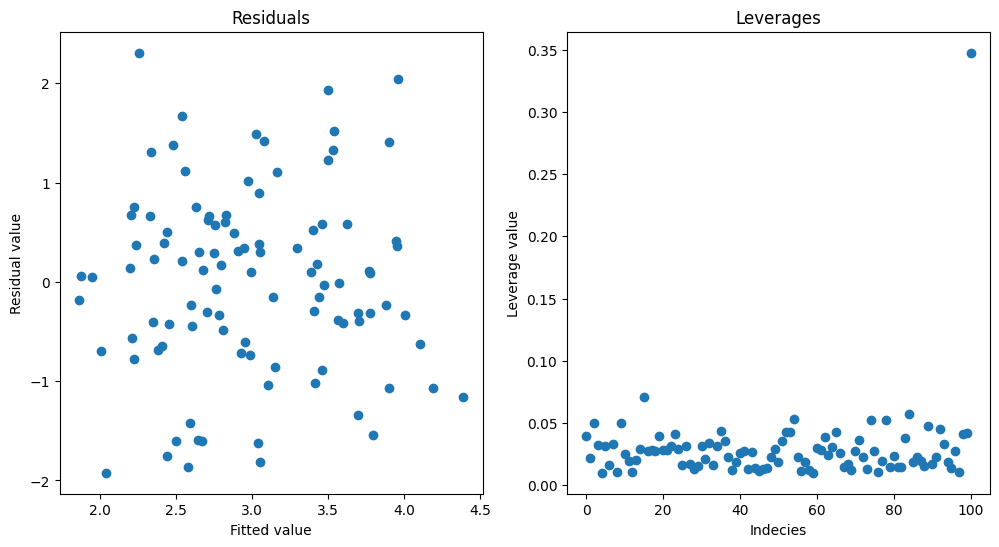

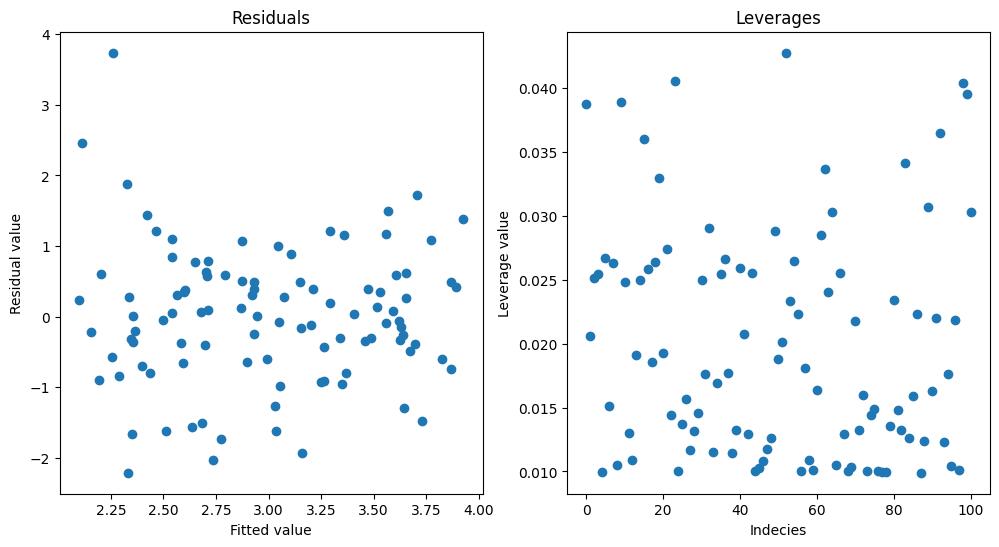

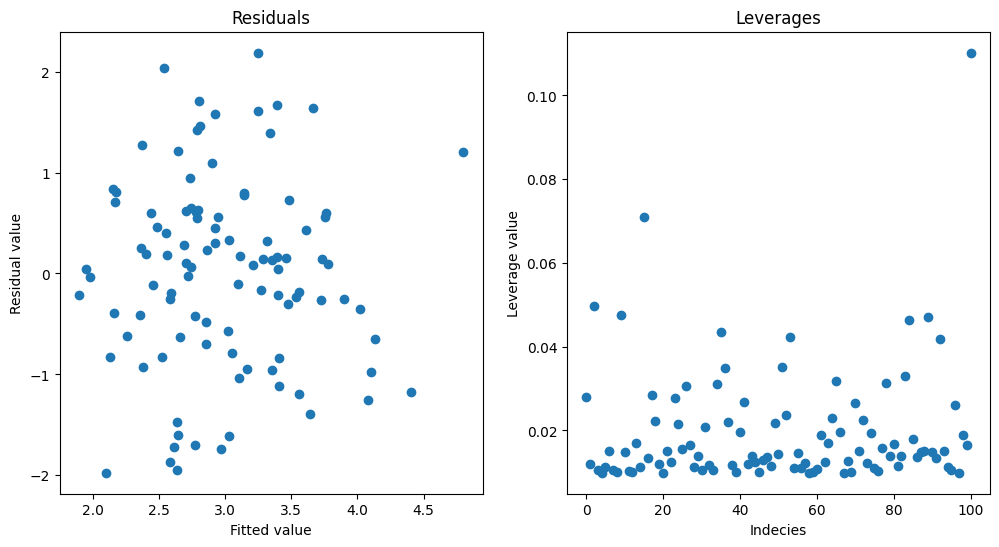

In [ ]:
print('Baseline Model') # The new point is both an outliar and a leverage
out_lev(base, 2, 101)

print('\n\nX1 Only Model') # The new point is only an outliar
out_lev(x1_only, 1, 101)

print('\n\nX2 Only Model') # The new point is only a leverage
out_lev(x2_only, 1, 101)

g. Adding a misread observation has had extreme effects on regression. First, it can be noted that the correlation between x1 and x2 drops by almost 10 points. The added point was a clear outliar on x1 vs x2 graph. It meant that the subsquent models had to treat x1 and x2 more distinctively, and the regression had less power to pick correct coefficients in models with only one of the predictors. Second, the added point proved to be a significant leverage in base- and x2-only models as well as an outlier in base- and x1-only models. The leverages "pull" the regression line towards themselves more significantly, skewing the prediction coefficients towards misread values.

## 15. Linear Regression on Boston

zn :
              coef  std err       t  P>|t|
intercept  4.4537    0.417  10.675    0.0
zn        -0.0739    0.016  -4.594    0.0 


indus :
              coef  std err      t  P>|t|
intercept -2.0637    0.667 -3.093  0.002
indus      0.5098    0.051  9.991  0.000 


chas :
              coef  std err      t  P>|t|
intercept  3.7444    0.396  9.453  0.000
chas      -1.8928    1.506 -1.257  0.209 


nox :
               coef  std err       t  P>|t|
intercept -13.7199    1.699  -8.073    0.0
nox        31.2485    2.999  10.419    0.0 


rm :
               coef  std err      t  P>|t|
intercept  20.4818    3.364  6.088    0.0
rm         -2.6841    0.532 -5.045    0.0 


age :
              coef  std err      t  P>|t|
intercept -3.7779    0.944 -4.002    0.0
age        0.1078    0.013  8.463    0.0 


dis :
              coef  std err       t  P>|t|
intercept  9.4993    0.730  13.006    0.0
dis       -1.5509    0.168  -9.213    0.0 


rad :
              coef  std err       t  P>|t|
inte

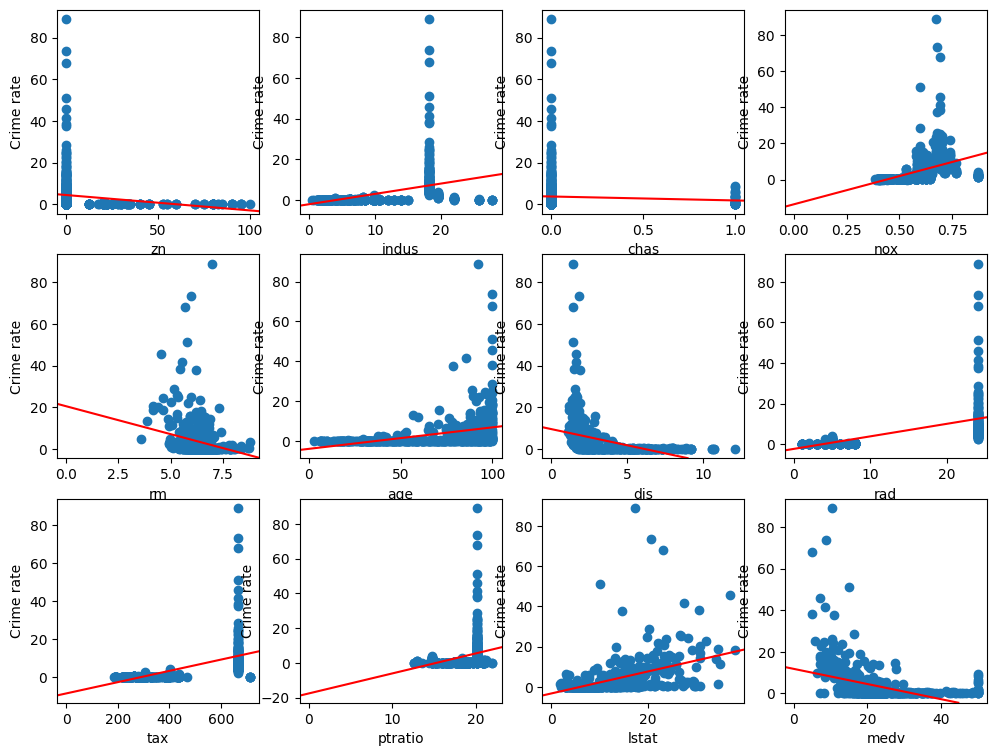

In [ ]:
Boston = pd.read_csv(path + 'Datasets/Boston.csv')
Boston = Boston.drop(columns=['Unnamed: 0'])
y = Boston['crim']

res = {}

fig, ax = subplots(ncols=4, nrows=3, figsize=(12, 9))
r = c = 0

for col in Boston.columns:
  if col == 'crim': continue

  # Run regression model
  X = Boston[col]
  X = MS([col]).fit_transform(Boston)

  model9 = sm.OLS(y, X)
  results9 = model9.fit()

  # Save regression results
  res[col] = results9

  # Draw data and regression line
  ax[r][c].scatter(Boston[col], y);
  ax[r][c].set_xlabel(col);
  ax[r][c].set_ylabel('Crime rate');

  ax[r][c].axline(xy1=(0, results9.params.iloc[0]), slope=results9.params.iloc[1], c='r', label='Regression Line');

  c += 1
  if c%4 == 0:
    c = 0
    r += 1

  # Print regression results
  print(col, ':\n', summarize(results9), '\n\n')

a. All regression models except 'crim' vs 'chas' proved to be statistically sognificant: their coefficients were large compared to standard error, leading to high t-statistics and small p-values for both the predictor and associated intercept. For 'crim' vs 'chas', the predictor coefficient was almost the magnitude of the standard error, leading to smaller t-statistic and high p-value. It must be noted, however, that all, except possibly 'crim' vs 'lstat' predictors exhibit non-linear trends, making it hard for the model to be accurate. Furthemore, the associated R^2 values must be small as these facts make linear models unreliable to explain the variability in data.

In [ ]:
X = Boston.drop(columns=['crim'])
X = MS(X.columns).fit_transform(X)

model91 = sm.OLS(y, X)
results91 = model91.fit()
print(results91.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           2.03e-56
Time:                        01:31:27   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.7784      7.082      1.946      0.0

b. Out of 13 coefficients, we can reject the null-hypothesis for 'zn', 'dis', 'rad', and 'medv'. On the p-value edge (slightly higher than 0.05) happened to be the intercept, 'nox', and 'lstat'. All others have high standard error compared to the coefficients, leading to low t-value and high p-value. The R^2 value of 45% is relatively high (but still low overall) given the non-linearity of the dataset, meaning that 45% of variation in the data can be explined via given predictors.

In [ ]:
# Combine coefficients into a single data frame
results9 = results91.params.to_frame()
results9 = results9.drop(index=['intercept'])
results9.columns = ['Multiple Regression Coefficients']
results9['Simple Regression Coefficients'] = 0.0

for pred in res.keys():
  results9.loc[pred, 'Simple Regression Coefficients'] = res[pred].params.iloc[1]

results9

,Multiple Regression Coefficients,Simple Regression Coefficients
zn,0.045710,-0.073935
indus,-0.058350,0.509776
chas,-0.825378,-1.892777
nox,-9.957587,31.248531
rm,0.628911,-2.684051
age,-0.000848,0.107786
dis,-1.012247,-1.550902
rad,0.612465,0.617911
tax,-0.003776,0.029742
ptratio,-0.304073,1.151983


np.float64(-0.9739640320288786)

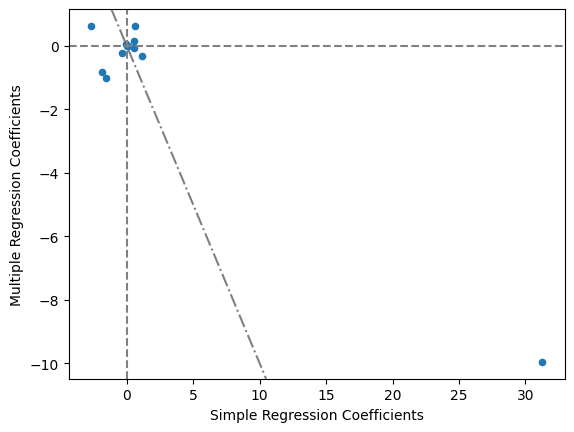

In [ ]:
ax = results9.plot(x='Simple Regression Coefficients', y='Multiple Regression Coefficients', kind='scatter')
ax.axhline(y=0, c='gray', linestyle='--')
ax.axvline(x=0, c='gray', linestyle='--')
ax.axline((0,0), slope=-1, c='gray', linestyle='-.')
np.corrcoef(results9['Simple Regression Coefficients'], results9['Multiple Regression Coefficients'])[0][1]

e. The coefficients of a multiple regression model have shifted dramatically compared to the simple regression model. Many of the values have flipped their signes; the correlation between the coefficients is significant (-97.4%). Such a response could be the result from collinearity, where the coefficients have "absorbed" the correlated predictors power in the simple models, but such behavior was decreased and more distributed in the multiple regression.

zn :
                           coef  std err      t  P>|t|
intercept               3.6135    0.372  9.709  0.000
poly(zn, degree=3)[0] -38.7498    8.372 -4.628  0.000
poly(zn, degree=3)[1]  23.9398    8.372  2.859  0.004
poly(zn, degree=3)[2] -10.0719    8.372 -1.203  0.230 


indus :
                              coef  std err       t  P>|t|
intercept                  3.6135    0.330  10.950  0.000
poly(indus, degree=3)[0]  78.5908    7.423  10.587  0.000
poly(indus, degree=3)[1] -24.3948    7.423  -3.286  0.001
poly(indus, degree=3)[2] -54.1298    7.423  -7.292  0.000 


chas :
                            coef  std err      t  P>|t|
intercept                3.6916    0.388  9.506  0.000
poly(chas, degree=3)[0] -0.1172    0.066 -1.784  0.075
poly(chas, degree=3)[1] -0.5808    0.236 -2.463  0.014
poly(chas, degree=3)[2] -0.7918    0.706 -1.122  0.263 


nox :
                            coef  std err       t  P>|t|
intercept                3.6135    0.322  11.237    0.0
poly(nox, degr

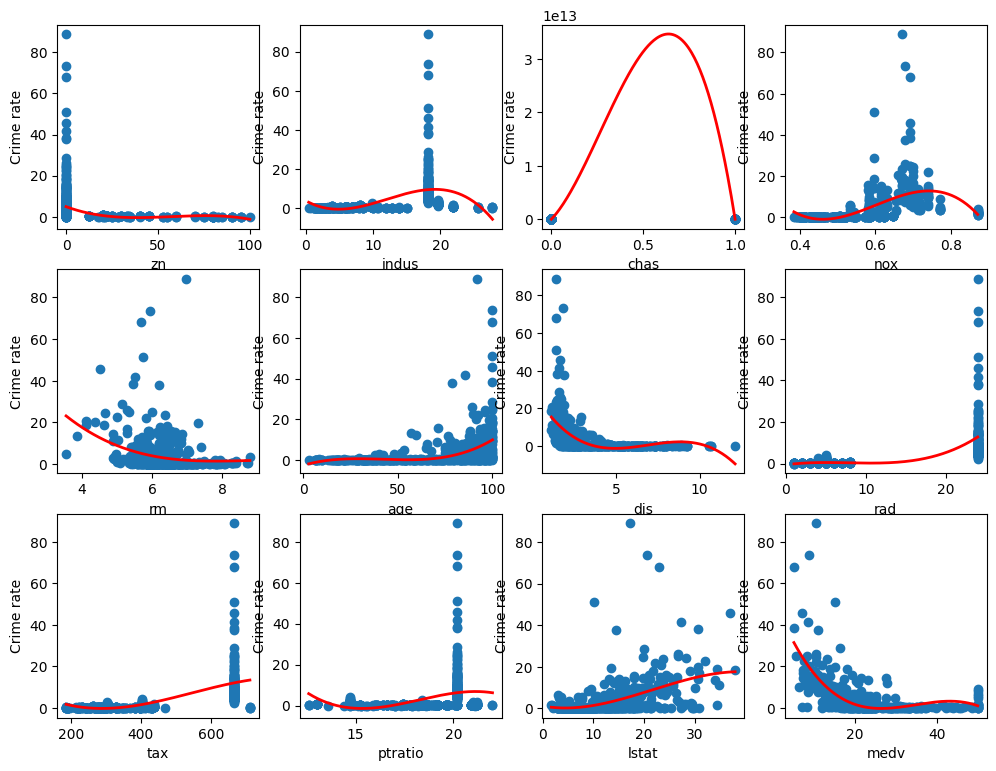

In [ ]:
fig, ax = subplots(ncols=4, nrows=3, figsize=(12, 9))
r = c = 0

for col in Boston.columns:
  if col == 'crim': continue

  # Run regression model
  ms = MS([poly(col, degree=3)])
  X = ms.fit_transform(Boston)
  results9 = sm.OLS(y, X).fit()
  res[col] = results9

  # Plot data
  ax[r, c].set(xlabel=col, ylabel="Crime rate")
  ax[r][c].scatter(Boston[col], y);

  # Plot the regression polynomial
  x_plot = np.linspace(Boston[col].min(), Boston[col].max(), 200)
  X_plot = ms.transform(pd.DataFrame({col: x_plot}))
  y_plot = results9.predict(X_plot)
  ax[r, c].plot(x_plot, y_plot, color="red", lw=2)

  c += 1
  if c%4 == 0:
    c = 0
    r += 1

  # Print regression results
  print(col, ':\n', summarize(results9), '\n\n')

Strong non-linear association between indus, nox, age, dis, ptratio, or medv, and crim. Their corresponding p-values for all 4 coefficients were statisticaly significant. The graph proves further that the polynomial regression fit was more appropriate for most predictors compared to the original graph (however, there must be more appropriate functions besides cubic to fit them).